In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rodrigoarede2003/penalty-kick-dataset-20202025")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\yassi\.cache\kagglehub\datasets\rodrigoarede2003\penalty-kick-dataset-20202025\versions\2


In [8]:
import pandas as pd
import numpy as np
df = pd.read_excel(path + "/real_data.xlsx")
df.head()

,Unnamed: 0,Country,player_id,player_name,Kicker_Foot,Kicker_Side,Goalie_Side,Outcome,goalkeer_name,goalkeeper_id,Home_Goals,Away_Goals,Minute,Team_Type,player_name.1,player_id.1,Unnamed: 16,goalkeer_name.1,goalkeeper_id.1
0,24/25,Portugal,1.0,Galeno,R,L,L,1.0,Andrew,1.0,0,0,30,H,Galeno,1.0,NaN,Andrew,1.0
1,24/25,Portugal,2.0,Namaso,R,L,R,1.0,Andrew,1.0,0,0,70,H,Namaso,2.0,NaN,Dani Figueira,2.0
2,24/25,Portugal,3.0,Safira,R,R,L,1.0,Dani Figueira,2.0,1,0,70,A,Safira,3.0,NaN,Ricardo Batista,3.0
3,24/25,Portugal,4.0,Reisinho,L,L,R,1.0,Ricardo Batista,3.0,0,0,77,A,Reisinho,4.0,NaN,Gabriel Batista,4.0
4,24/25,Portugal,1.0,Galeno,R,L,R,1.0,Gabriel Batista,4.0,1,0,25,A,Alan,5.0,NaN,Nico Mantl,5.0


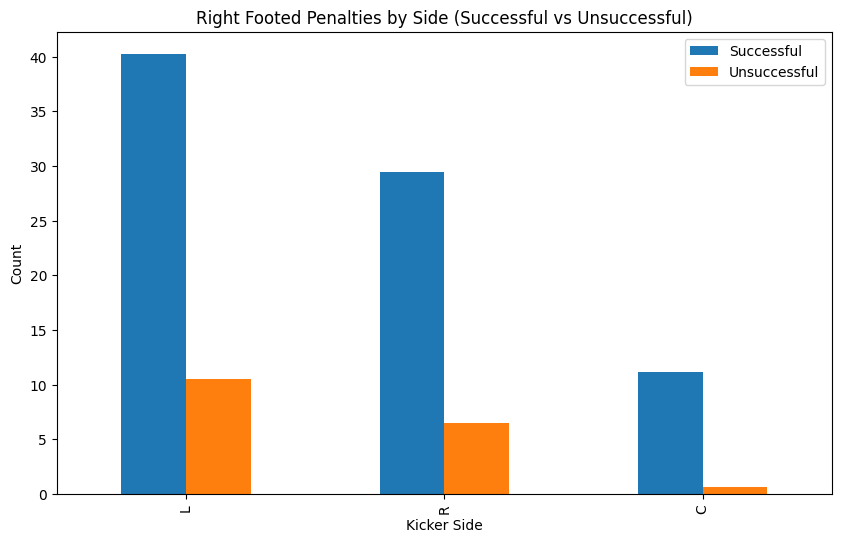

In [4]:
import matplotlib.pyplot as plt

# Filter data for successful and unsuccessful penalties as percentages
successful = 100 * df[(df["Kicker_Foot"] == "R") & (df["Outcome"] == 1)]["Kicker_Side"].value_counts() / len(df[(df["Kicker_Foot"] == "R")]["Kicker_Side"])
unsuccessful = 100 * df[(df["Kicker_Foot"] == "R") & (df["Outcome"] == 0)]["Kicker_Side"].value_counts() / len(df[(df["Kicker_Foot"] == "R")]["Kicker_Side"])
# Combine the results into a single DataFrame
comparison = pd.DataFrame({
    "Successful": successful,
    "Unsuccessful": unsuccessful
}).fillna(0)  # Fill NaN with 0 for missing values

# Plot the data
comparison.plot(kind="bar", title="Right Footed Penalties by Side (Successful vs Unsuccessful)", figsize=(10, 6))
plt.xlabel("Kicker Side")
plt.ylabel("Count")
plt.show()

In [9]:
df.head()

,Unnamed: 0,Country,player_id,player_name,Kicker_Foot,Kicker_Side,Goalie_Side,Outcome,goalkeer_name,goalkeeper_id,Home_Goals,Away_Goals,Minute,Team_Type,player_name.1,player_id.1,Unnamed: 16,goalkeer_name.1,goalkeeper_id.1
0,24/25,Portugal,1.0,Galeno,R,L,L,1.0,Andrew,1.0,0,0,30,H,Galeno,1.0,NaN,Andrew,1.0
1,24/25,Portugal,2.0,Namaso,R,L,R,1.0,Andrew,1.0,0,0,70,H,Namaso,2.0,NaN,Dani Figueira,2.0
2,24/25,Portugal,3.0,Safira,R,R,L,1.0,Dani Figueira,2.0,1,0,70,A,Safira,3.0,NaN,Ricardo Batista,3.0
3,24/25,Portugal,4.0,Reisinho,L,L,R,1.0,Ricardo Batista,3.0,0,0,77,A,Reisinho,4.0,NaN,Gabriel Batista,4.0
4,24/25,Portugal,1.0,Galeno,R,L,R,1.0,Gabriel Batista,4.0,1,0,25,A,Alan,5.0,NaN,Nico Mantl,5.0


In [12]:
# Vectorized assignment: positive if home leading when Team_Type is 'H', else opponent lead
df["score_diff"] = np.where(df["Team_Type"] == "H", df["Home_Goals"] - df["Away_Goals"], df["Away_Goals"] - df["Home_Goals"])
df["score"] = np.where(df["score_diff"] > 0, "Leading", np.where(df["score_diff"] < 0, "Trailing", "Tied"))

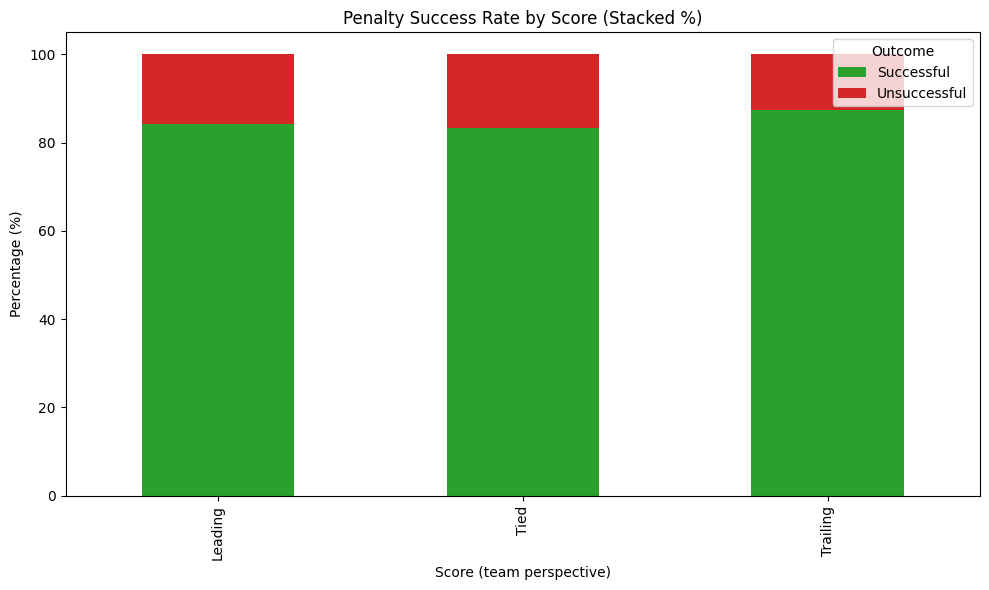

In [ ]:
import matplotlib.pyplot as plt
# Filter data for successful and unsuccessful penalties as percentages
successful = df[df["Outcome"] == 1]["score"].value_counts() 
unsuccessful = df[df["Outcome"] == 0]["score"].value_counts() 
# Combine the results into a single DataFrame
comparison = pd.DataFrame({
    "Successful": successful,
    "Unsuccessful": unsuccessful,
    "Total": successful + unsuccessful
}).fillna(0)  # Fill NaN with 0 for missing values
comparison["successful_rate"] = comparison["Successful"] / comparison["Total"] * 100
comparison["unsuccessful_rate"] = comparison["Unsuccessful"] / comparison["Total"] * 100
# Plot the data as stacked bar chart
ax = comparison[["successful_rate", "unsuccessful_rate"]].plot(kind="bar", stacked=True, title="Penalty Success Rate by Score (Stacked %)", figsize=(10, 6), color=['#2ca02c', '#d62728'])
plt.xlabel("Score (team perspective)")
plt.ylabel("Percentage (%)")
plt.legend(title="Outcome", labels=["Successful", "Unsuccessful"])

# Add percentage labels on each bar segment
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()